In [1]:
# >>> repo-root chdir setup >>>
import os
from pathlib import Path
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists():
            return p
    return start
_root = _find_repo_root(Path(os.getcwd()).resolve())
if Path(os.getcwd()).resolve() != _root:
    os.chdir(_root)
print('CWD:', os.getcwd())
# <<< repo-root chdir setup <<<


CWD: C:\Users\scoti\PycharmProjects\ai-vpn-firewall


# Model Stability Audit Notebook

This notebook audits model metric stability, threshold selection, and bootstrap CIs for the CLEAN pipeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from pathlib import Path

seed_metrics = pd.read_csv("artifacts/validation/model_seed_stability.csv")

## 1. Metric variability across seeds

C:\Users\scoti\AppData\Local\Temp\ipykernel_7628\2536020488.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


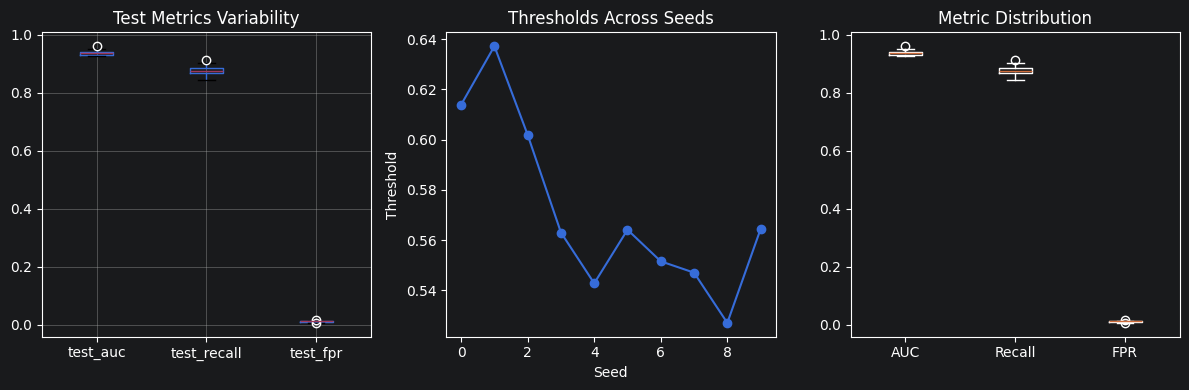

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

seed_metrics.boxplot(
    column=["test_auc", "test_recall", "test_fpr"],
    ax=axes[0]
)
axes[0].set_title("Test Metrics Variability")

axes[1].plot(
    seed_metrics["seed"],
    seed_metrics["threshold"],
    marker="o"
)
axes[1].set_title("Thresholds Across Seeds")
axes[1].set_xlabel("Seed")
axes[1].set_ylabel("Threshold")

axes[2].boxplot(
    [
        seed_metrics["test_auc"],
        seed_metrics["test_recall"],
        seed_metrics["test_fpr"]
    ],
    labels=["AUC", "Recall", "FPR"]
)
axes[2].set_title("Metric Distribution")

plt.tight_layout()
plt.savefig("figures/validation/metric_variability_across_seeds.png")
plt.show()

## 2. Threshold distribution across seeds

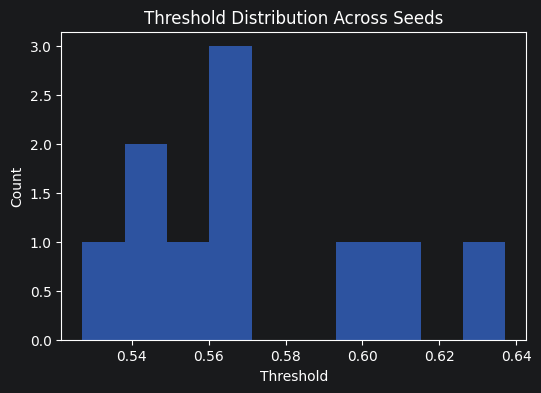

In [4]:
plt.figure(figsize=(6, 4))

seed_metrics["threshold"].plot(
    kind="hist",
    bins=10,
    alpha=0.7
)

plt.title("Threshold Distribution Across Seeds")
plt.xlabel("Threshold")
plt.ylabel("Count")

plt.savefig("figures/validation/threshold_distribution_across_seeds.png")
plt.show()

## 3. Bootstrap confidence intervals

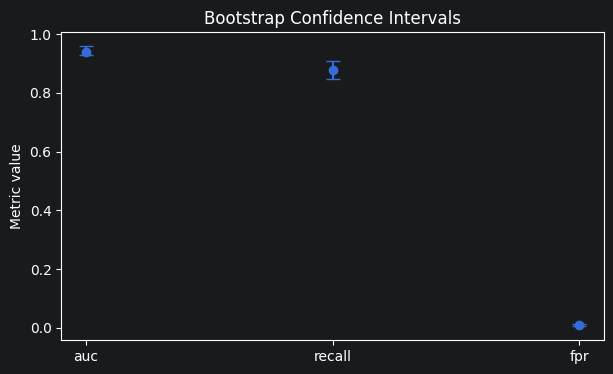

In [5]:
summary = pd.read_csv("artifacts/validation/model_stability_summary.csv")

metrics = ["auc", "recall", "fpr"]

ci_lowers = [summary[f"{m}_ci_lower"][0] for m in metrics]
ci_uppers = [summary[f"{m}_ci_upper"][0] for m in metrics]
means = [summary[f"{m}"][0] for m in metrics]

plt.figure(figsize=(7, 4))

plt.errorbar(
    metrics,
    means,
    yerr=[
        np.array(means) - np.array(ci_lowers),
        np.array(ci_uppers) - np.array(means)
    ],
    fmt="o",
    capsize=5
)

plt.title("Bootstrap Confidence Intervals")
plt.ylabel("Metric value")

plt.savefig("figures/validation/bootstrap_confidence_intervals.png")
plt.show()

## 4. Save model stability summary

In [6]:
summary.to_json(
    "artifacts/validation/model_stability_summary.json",
    orient="records",
    indent=2
)

summary.head()

,auc,auc_ci_lower,auc_ci_upper,recall,recall_ci_lower,recall_ci_upper,fpr,fpr_ci_lower,fpr_ci_upper,n_seeds
0,0.937811,0.927386,0.958501,0.877657,0.84782,0.909747,0.010263,0.005661,0.014796,10
